# Примеры

## Directional persistence diagrams on MNIST

In [44]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

import src.filtrations
from src.registry import FILTRATIONS

In [51]:
dataset = MNIST(root="../data/image", train=True, download=True)
idx = 2
image_pil, label = dataset[idx]
image = ToTensor()(image_pil)
image.shape, image.dtype, float(image.min()), float(image.max()), label

(torch.Size([1, 28, 28]), torch.float32, 0.0, 1.0, 4)

In [52]:
alphas = [0, 90, 180, 270]
filtration = FILTRATIONS.get("pht_directional")(params={"alphas": alphas, "agg": "add"})
diagram = filtration(image)

points = diagram.points.numpy()
points = points[points[:, 3] == 0.0]
points.shape, sorted(set(points[:, 4].tolist()))

((43, 6), [0.0, 90.0, 180.0, 270.0])

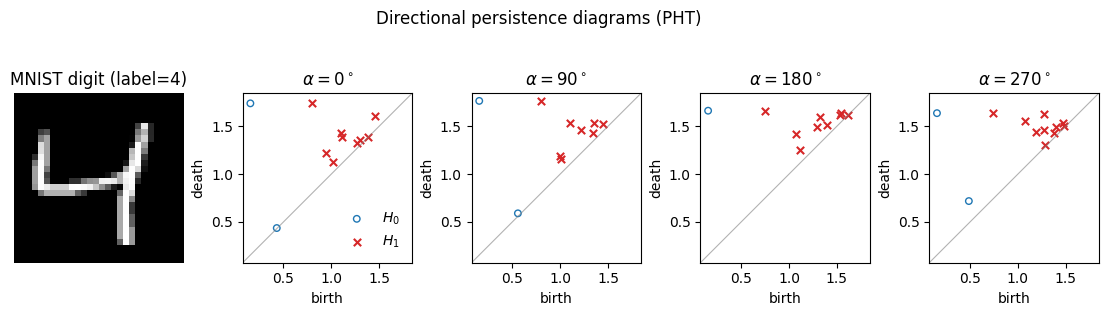

In [53]:
fig = plt.figure(figsize=(14, 3.2))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 1, 1], wspace=0.35)

ax_img = fig.add_subplot(gs[0, 0])
ax_img.imshow(image_pil, cmap="gray")
ax_img.set_title(f"MNIST digit (label={label})")
ax_img.axis("off")

finite = points[np.isfinite(points[:, :2]).all(axis=1)]
lo = float(finite[:, :2].min())
hi = float(finite[:, :2].max())
pad = 0.05 * (hi - lo)
lo, hi = lo - pad, hi + pad

for j, alpha in enumerate(alphas):
    ax = fig.add_subplot(gs[0, j + 1])
    sel = points[points[:, 4] == alpha]
    h0 = sel[sel[:, 2] == 0]
    h1 = sel[sel[:, 2] == 1]
    ax.plot([lo, hi], [lo, hi], color="gray", linewidth=0.8, alpha=0.6)
    ax.scatter(h0[:, 0], h0[:, 1], marker="o", s=22, facecolors="none",
               edgecolors="C0", label=r"$H_0$")
    ax.scatter(h1[:, 0], h1[:, 1], marker="x", s=28, color="C3", label=r"$H_1$")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_title(rf"$\alpha={alpha}^\circ$")
    ax.set_xlabel("birth"); ax.set_ylabel("death")
    if j == 0:
        ax.legend(loc="lower right", frameon=False)

fig.suptitle("Directional persistence diagrams (PHT)", y=1.02)
plt.show()

In [54]:
fig.savefig("../report/figures/mnist_directional_pht.png", dpi=200, bbox_inches="tight")